# Train, validation, test: why you need all three

### Tuning against a test set, done the way people actually do it, with the damage measured after every look

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why a set you have looked at twice is no longer a test set, how fast a test score drifts away from honest performance as a function of how often it was consulted, what the third split buys, what nested cross-validation measures that a single search cannot, and the two situations where a random split is the wrong split |
| **You should already know** | [What machine learning actually does](../01-what-machine-learning-does/) |
| **Datasets** | UCI Dry Bean, UCI Bike Sharing, Breast Cancer Wisconsin, plus a simulation |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [01-03 Overfitting and underfitting](../03-overfitting-and-underfitting/) · [01-04 Cross-validation](../04-cross-validation/) |

---

## 1. Three splits, three jobs

The previous chapter used two pieces: rows to fit on, rows to score on. That is
enough for exactly one model. It stops being enough the moment you have a
choice to make.

Here is the situation everyone is actually in. You fit a model, score it on the
held-out rows, and the number is disappointing. So you change something, a depth
limit or a learning rate or which columns go in, and score again. Better. You do
it again. Better still. After an afternoon of this you have a model whose
held-out score is much improved, and you write that score in the report.

Nothing in that story involves fitting on test rows. No line of code was wrong.
And the number in the report is still too high, because the held-out set stopped
being held out the second time you looked at it. **You did not train the model's
parameters on those rows. You trained your own choices on them,** and choices are
parameters too.

The three splits divide the labour so that each set answers a question exactly
once.

| Set | Who uses it | What it decides |
|---|---|---|
| **Training** | the fitting algorithm | the model's parameters |
| **Validation** | you | which model, which hyperparameters, when to stop |
| **Test** | nobody, until the end | the number you report |

The rest of this notebook is the measurement. I am going to tune against a test
set the way it happens in practice, and track the difference between what that
test set says and what a large untouched pool of fresh rows says, as a function
of how many times the test set was consulted.

In [1]:
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets, data

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

## 2. The maths: why the winner is always flattered

Suppose you try $k$ candidate models and they are all, in truth, equally good,
worth $\mu$ on fresh data. You score each one on a test set of $n$ rows. Each
score is the truth plus noise:

$$s_j = \mu + \varepsilon_j, \qquad \varepsilon_j \sim \mathcal{N}(0, \sigma^2)$$

For accuracy on $n$ held-out rows that noise has a size you can write down,
because the number of correct predictions is a sum of Bernoulli draws:

$$\sigma = \sqrt{\frac{\mu(1-\mu)}{n}}$$

You report $\max_j s_j$. The expectation of a maximum is not the maximum of the
expectations. For $k$ independent standard normals the expected maximum grows
like

$$\mathbb{E}\left[\max_{j \le k} Z_j\right] \approx \sqrt{2 \ln k}$$

so the score you report is inflated by roughly

$$\text{optimism} \approx \sigma \sqrt{2 \ln k}
= \sqrt{\frac{\mu(1-\mu)}{n}} \cdot \sqrt{2 \ln k}$$

Three things fall out of that expression, and all three are testable.

The inflation **grows with the number of candidates**, but slowly, as the square
root of a logarithm. Going from ten candidates to a hundred does not multiply the
damage by ten.

The inflation **shrinks as the test set grows**, as one over the square root of
$n$. A test set four times larger halves it.

And the inflation **does not need any candidate to be overfitted**. Every model
in the derivation is equally good. The optimism is manufactured entirely by the
act of choosing, which is why no amount of care inside the models prevents it.

## 3. From scratch: the winner's curse in eight lines

Before touching real data, the simulation. Every candidate is worth exactly the
same, the measurement noise is exactly the binomial noise of a test set of $n$
rows, and the only thing that happens is a maximum.

In [2]:
def winners_curse(k, n_test, truth=0.90, repeats=4000, seed=SEED):
    """Report the best of k noisy measurements of k identical candidates."""
    sigma = np.sqrt(truth * (1 - truth) / n_test)
    rng = np.random.default_rng(seed)
    draws = rng.normal(truth, sigma, size=(repeats, k))
    return float(draws.max(axis=1).mean() - truth), sigma


CANDIDATES = [1, 2, 5, 10, 20, 50, 100, 500, 1000]

rows = []
for n_test in [100, 250, 1000]:
    for k in CANDIDATES:
        measured, sigma = winners_curse(k, n_test)
        rows.append({"test rows": n_test, "candidates": k,
                     "measured optimism": measured,
                     "sigma sqrt(2 ln k)": sigma * np.sqrt(2 * np.log(k)) if k > 1 else 0.0})

curse = pd.DataFrame(rows)
print(curse.pivot(index="candidates", columns="test rows", values="measured optimism")
      .to_string(float_format="{:+.4f}".format))
print("\nmeasured optimism against the closed form, 250 test rows:")
print(curse[curse["test rows"] == 250].to_string(
    index=False, formatters={"measured optimism": "{:+.4f}".format,
                             "sigma sqrt(2 ln k)": "{:.4f}".format}))

test rows     100     250     1000
candidates                        
1          -0.0005 -0.0003 -0.0001
2          +0.0173 +0.0109 +0.0055
5          +0.0349 +0.0221 +0.0110
10         +0.0464 +0.0293 +0.0147
20         +0.0562 +0.0355 +0.0178
50         +0.0676 +0.0427 +0.0214
100        +0.0751 +0.0475 +0.0237
500        +0.0911 +0.0576 +0.0288
1000       +0.0972 +0.0615 +0.0307

measured optimism against the closed form, 250 test rows:
 test rows  candidates measured optimism sigma sqrt(2 ln k)
       250           1           -0.0003             0.0000
       250           2           +0.0109             0.0223
       250           5           +0.0221             0.0340
       250          10           +0.0293             0.0407
       250          20           +0.0355             0.0464
       250          50           +0.0427             0.0531
       250         100           +0.0475             0.0576
       250         500           +0.0576             0.0669
       250      

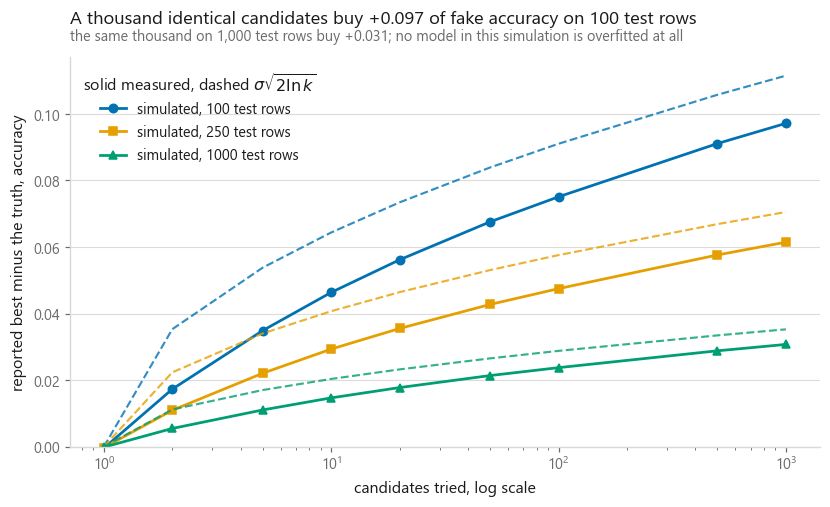

In [3]:
fig, ax = plt.subplots(figsize=(8.8, 4.6))

for i, n_test in enumerate([100, 250, 1000]):
    part = curse[curse["test rows"] == n_test]
    ax.plot(part["candidates"], part["measured optimism"],
            color=style.PALETTE[i], marker=style.MARKERS[i], ls=style.DASHES[0],
            lw=1.8, label=f"simulated, {n_test} test rows")
    ax.plot(part["candidates"], part["sigma sqrt(2 ln k)"],
            color=style.PALETTE[i], ls=style.DASHES[1], lw=1.4, alpha=0.8)

ax.set_xscale("log")
ax.set_xlabel("candidates tried, log scale")
ax.set_ylabel("reported best minus the truth, accuracy")
ax.set_ylim(0, None)
ax.legend(loc="upper left", title="solid measured, dashed $\\sigma\\sqrt{2\\ln k}$")

big = curse[(curse["test rows"] == 100) & (curse["candidates"] == 1000)].iloc[0]
small = curse[(curse["test rows"] == 1000) & (curse["candidates"] == 1000)].iloc[0]
style.title(ax,
            f"A thousand identical candidates buy {big['measured optimism']:+.3f} of fake accuracy "
            f"on 100 test rows",
            f"the same thousand on 1,000 test rows buy {small['measured optimism']:+.3f}; "
            f"no model in this simulation is overfitted at all")

style.save(fig, FIG / "fig-01-winners-curse.png")

The closed form tracks the simulation closely enough that the dashed lines are
hard to see, which means the square root of a logarithm is the right shape and
the test-set size is the dial that matters most.

That is a simulation with the answer written into it. The question is whether
real model selection behaves the same way.

## 4. Tuning against the test set, on real data

The setup mimics an afternoon of work. A small training set, a small test set,
and a stream of candidate models tried one after another, keeping whichever has
the best test score so far. That is what people do, and it is not obviously
wrong until you can see the alternative.

The alternative here is a large pool of rows that is never touched by anything.
Call it the fresh pool. It plays the part of reality: the honest score of any
model is its score on that pool. Real projects do not have one, which is exactly
why the drift below goes unnoticed.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_bean, y_bean = datasets.dry_bean()
pick = np.random.default_rng(SEED).choice(len(X_bean), 6000, replace=False)
X_bean = X_bean.iloc[pick].reset_index(drop=True)
y_bean = y_bean.iloc[pick].reset_index(drop=True)

N_TRAIN, N_VAL = 500, 250
N_CANDIDATES, N_REPEATS = 120, 15

print(f"rows available   : {len(X_bean):,}")
print(f"classes          : {y_bean.nunique()}")
print(f"training rows    : {N_TRAIN}")
print(f"validation rows  : {N_VAL}")
print(f"candidates tried : {N_CANDIDATES}")
print(f"repeats          : {N_REPEATS}")


def draw_candidate(gen):
    """One random hyperparameter setting, the way a hand-tuning session wanders."""
    return DecisionTreeClassifier(
        max_depth=int(gen.integers(2, 16)),
        min_samples_leaf=int(gen.integers(1, 30)),
        max_features=float(gen.uniform(0.3, 1.0)),
        criterion=["gini", "entropy"][int(gen.integers(0, 2))],
        random_state=int(gen.integers(0, 10_000)),
    )


def one_session(seed, n_test):
    """Fit N_CANDIDATES models; track the best-so-far under two selection rules.

    Returns, per candidate index k:
      test_best   the running best test score  (what a test-tuner would report)
      fresh_of_test  that model's score on the untouched pool  (the truth)
      test_of_val    the test score of the model chosen on validation
      fresh_of_val   that model's score on the untouched pool
    """
    X_tr, X_rest, y_tr, y_rest = train_test_split(
        X_bean, y_bean, train_size=N_TRAIN, random_state=seed, stratify=y_bean)
    X_va, X_rest, y_va, y_rest = train_test_split(
        X_rest, y_rest, train_size=N_VAL, random_state=seed, stratify=y_rest)
    X_te, X_fr, y_te, y_fr = train_test_split(
        X_rest, y_rest, train_size=n_test, random_state=seed, stratify=y_rest)

    gen = np.random.default_rng(10_000 + seed)
    best_test = best_val = -np.inf
    fresh_at_test = test_at_val = fresh_at_val = np.nan
    out = np.empty((N_CANDIDATES, 4))

    for k in range(N_CANDIDATES):
        model = draw_candidate(gen).fit(X_tr, y_tr)
        s_test = model.score(X_te, y_te)
        s_val = model.score(X_va, y_va)
        if s_test > best_test:                       # the mistake, made explicitly
            best_test, fresh_at_test = s_test, model.score(X_fr, y_fr)
        if s_val > best_val:                         # the honest rule
            best_val = s_val
            test_at_val, fresh_at_val = s_test, model.score(X_fr, y_fr)
        out[k] = (best_test, fresh_at_test, test_at_val, fresh_at_val)

    return out, len(X_fr)


sessions = {}
for n_test in [100, 250, 1000]:
    stack = np.stack([one_session(r, n_test)[0] for r in range(N_REPEATS)])
    sessions[n_test] = stack
    print(f"finished the sweep at {n_test} test rows, "
          f"{N_REPEATS * N_CANDIDATES:,} models fitted")

rows available   : 6,000
classes          : 7
training rows    : 500
validation rows  : 250
candidates tried : 120
repeats          : 15


finished the sweep at 100 test rows, 1,800 models fitted


finished the sweep at 250 test rows, 1,800 models fitted


finished the sweep at 1000 test rows, 1,800 models fitted


In [5]:
main = sessions[250]
looks = np.arange(1, N_CANDIDATES + 1)

report = []
for k in [1, 2, 5, 10, 20, 50, 120]:
    reported = main[:, k - 1, 0].mean()
    honest = main[:, k - 1, 1].mean()
    report.append({"times the test set was consulted": k,
                   "test score reported": reported,
                   "honest score of that model": honest,
                   "optimism": reported - honest})

report = pd.DataFrame(report)
print(report.to_string(index=False, formatters={
    "test score reported": "{:.4f}".format,
    "honest score of that model": "{:.4f}".format,
    "optimism": "{:+.4f}".format}))

late_reported = main[:, -1, 0].mean() - main[:, 19, 0].mean()
late_honest = main[:, -1, 1].mean() - main[:, 19, 1].mean()
print(f"\nfrom look 20 to look 120, the reported test score improved by {late_reported:+.4f}")
print(f"over the same stretch, honest performance improved by        {late_honest:+.4f}")
print(f"share of the late improvement that was real                 : "
      f"{late_honest / late_reported:.1%}")

 times the test set was consulted test score reported honest score of that model optimism
                                1              0.8480                     0.8457  +0.0023
                                2              0.8611                     0.8537  +0.0074
                                5              0.8731                     0.8644  +0.0087
                               10              0.8803                     0.8680  +0.0123
                               20              0.8864                     0.8703  +0.0161
                               50              0.8979                     0.8739  +0.0240
                              120              0.9035                     0.8747  +0.0288

from look 20 to look 120, the reported test score improved by +0.0171
over the same stretch, honest performance improved by        +0.0044
share of the late improvement that was real                 : 25.7%


The two columns start together and separate. That separation is the whole
argument for the third split, and the last line is the part I would put in front
of anyone reporting a tuned score: past the first couple of dozen looks, almost
all of the apparent improvement is the test set being mined rather than the model
getting better.

The honest column does keep rising a little, so tuning is not worthless. It is
worth far less than the number on the screen says.

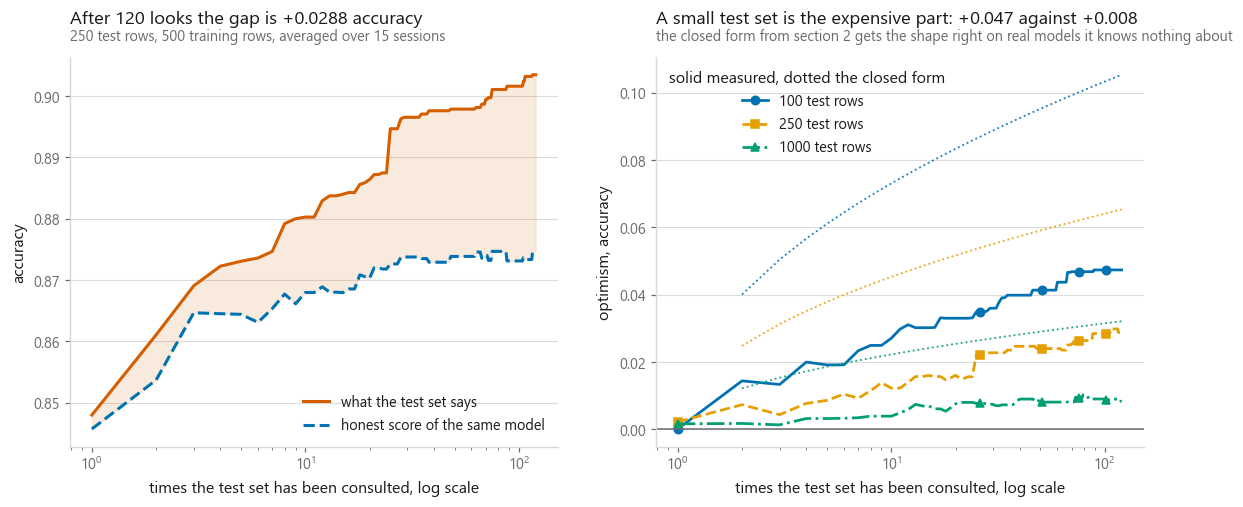

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))

axes[0].plot(looks, main[:, :, 0].mean(axis=0), color=style.HIGHLIGHT,
             ls=style.DASHES[0], lw=2.0, label="what the test set says")
axes[0].plot(looks, main[:, :, 1].mean(axis=0), color=style.PALETTE[0],
             ls=style.DASHES[1], lw=2.0, marker=None, label="honest score of the same model")
axes[0].fill_between(looks, main[:, :, 1].mean(axis=0), main[:, :, 0].mean(axis=0),
                     color=style.HIGHLIGHT, alpha=0.13)
axes[0].set_xscale("log")
axes[0].set_xlabel("times the test set has been consulted, log scale")
axes[0].set_ylabel("accuracy")
axes[0].legend(loc="lower right")
style.title(axes[0],
            f"After {N_CANDIDATES} looks the gap is {report.iloc[-1]['optimism']:+.4f} accuracy",
            f"250 test rows, {N_TRAIN} training rows, averaged over {N_REPEATS} sessions")

for i, n_test in enumerate([100, 250, 1000]):
    stack = sessions[n_test]
    gap = (stack[:, :, 0] - stack[:, :, 1]).mean(axis=0)
    axes[1].plot(looks, gap, color=style.PALETTE[i], ls=style.DASHES[i],
                 marker=style.MARKERS[i], markevery=25, lw=1.8,
                 label=f"{n_test} test rows")
    truth = stack[:, :, 1].mean()
    sigma = np.sqrt(truth * (1 - truth) / n_test)
    axes[1].plot(looks[1:], sigma * np.sqrt(2 * np.log(looks[1:])),
                 color=style.PALETTE[i], ls=":", lw=1.2, alpha=0.9)

axes[1].set_xscale("log")
axes[1].set_xlabel("times the test set has been consulted, log scale")
axes[1].set_ylabel("optimism, accuracy")
axes[1].axhline(0, color=style.MUTED, lw=1.0)
axes[1].legend(loc="upper left", title="solid measured, dotted the closed form")
small_gap = (sessions[1000][:, -1, 0] - sessions[1000][:, -1, 1]).mean()
big_gap = (sessions[100][:, -1, 0] - sessions[100][:, -1, 1]).mean()
style.title(axes[1],
            f"A small test set is the expensive part: {big_gap:+.3f} against {small_gap:+.3f}",
            "the closed form from section 2 gets the shape right on real models it knows nothing about")

style.save(fig, FIG / "fig-02-tuning-against-test.png")

The dotted lines are section 2's formula, computed from nothing but the honest
accuracy and the test-set size. It was derived for identical candidates measured
independently, and here the candidates differ in quality and share a training
set, so agreement was not owed. Where it disagrees, read the measured line.

The practical reading is the second panel. Consulting a test set a hundred times
is not the problem by itself. Consulting a **small** test set a hundred times is.

## 5. The three-way split, and what it costs

The fix is boring, which is why it works. Carve a validation set out of the
training data, do all the choosing against it, and touch the test set once at the
end. Every candidate above was also scored on a validation set, so the comparison
needs no new fitting.

In [7]:
procedures = []
for label, reported_col, honest_col in [
        ("tune on test, report test", 0, 1),
        ("tune on validation, report test", 2, 3)]:
    reported = main[:, -1, reported_col].mean()
    honest = main[:, -1, honest_col].mean()
    procedures.append({"procedure": label, "score reported": reported,
                       "honest score": honest, "optimism": reported - honest})

# One candidate, no choosing at all: the test score is unbiased by construction.
procedures.append({"procedure": "no tuning, first candidate",
                   "score reported": main[:, 0, 0].mean(),
                   "honest score": main[:, 0, 1].mean(),
                   "optimism": main[:, 0, 0].mean() - main[:, 0, 1].mean()})

procedures = pd.DataFrame(procedures)
print(procedures.to_string(index=False, formatters={
    "score reported": "{:.4f}".format, "honest score": "{:.4f}".format,
    "optimism": "{:+.4f}".format}))

print(f"\nhonest performance, tuned on test       : {main[:, -1, 1].mean():.4f}")
print(f"honest performance, tuned on validation : {main[:, -1, 3].mean():.4f}")

                      procedure score reported honest score optimism
      tune on test, report test         0.9035       0.8747  +0.0288
tune on validation, report test         0.8805       0.8768  +0.0037
     no tuning, first candidate         0.8480       0.8457  +0.0023

honest performance, tuned on test       : 0.8747
honest performance, tuned on validation : 0.8768


Read that table in two directions.

Down the optimism column: the procedure that consults the test set once reports a
number close to the truth, and the procedure that consults it a hundred and twenty
times does not.

Across the last two printed lines: the models chosen the honest way and the
dishonest way are not far apart in real quality. Tuning against the test set did
not produce a worse model here. It produced the same sort of model with a
dishonest number attached, which is a subtler failure and a harder one to notice,
because nothing about the model looks wrong when it disappoints in production.

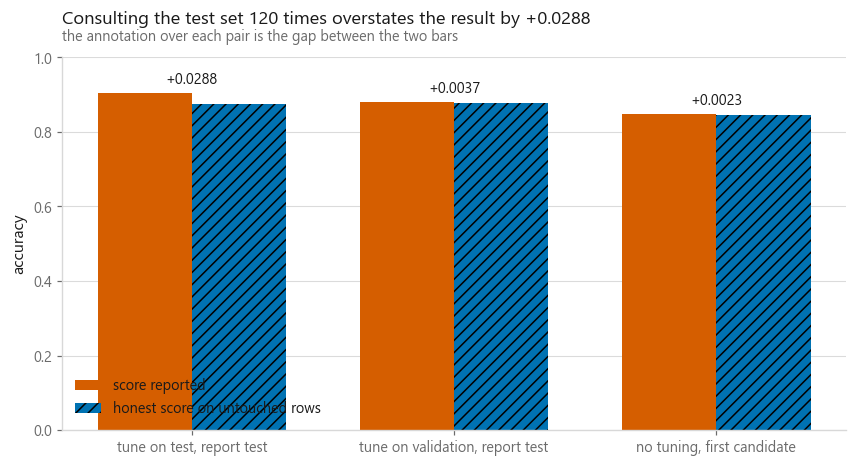

In [8]:
fig, ax = plt.subplots(figsize=(9.2, 4.4))

x = np.arange(len(procedures))
width = 0.36
ax.bar(x - width / 2, procedures["score reported"], width,
       color=style.HIGHLIGHT, label="score reported", hatch="")
ax.bar(x + width / 2, procedures["honest score"], width,
       color=style.PALETTE[0], label="honest score on untouched rows", hatch="///")

ax.set_xticks(x, procedures["procedure"], fontsize=9.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("accuracy")
ax.legend(loc="lower left")
for i, row in procedures.iterrows():
    ax.annotate(f"{row['optimism']:+.4f}", (i, max(row['score reported'], row['honest score'])),
                xytext=(0, 6), textcoords="offset points", ha="center",
                fontsize=9.5, color=style.INK)

worst = procedures.loc[procedures["optimism"].idxmax()]
style.title(ax,
            f"Consulting the test set {N_CANDIDATES} times overstates the result by "
            f"{worst['optimism']:+.4f}",
            "the annotation over each pair is the gap between the two bars")

style.save(fig, FIG / "fig-03-three-procedures.png")

### Nested cross-validation, when you cannot afford three sets

A three-way split is expensive on small data: rows spent on validation are rows
the model never learns from. Nested cross-validation buys the same honesty
without a permanent validation set, by putting the whole search inside an outer
fold.

The inner loop chooses hyperparameters. The outer loop scores the **procedure**,
search included, on rows that procedure never saw. What comes out is not the
score of one model. It is an estimate of how well this way of building a model
does on new data, which is usually the thing you wanted.

In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X_bc, y_bc = datasets.breast_cancer()
small = np.random.default_rng(SEED).choice(len(X_bc), 200, replace=False)
X_small, y_small = X_bc.iloc[small], y_bc.iloc[small]

grid = {"model__C": [0.01, 0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.001, 0.01, 0.1]}
pipe = Pipeline([("scale", StandardScaler()), ("model", SVC())])
inner = StratifiedKFold(5, shuffle=True, random_state=SEED)
outer = StratifiedKFold(5, shuffle=True, random_state=SEED + 1)

search = GridSearchCV(pipe, grid, cv=inner, n_jobs=-1).fit(X_small, y_small)
nested = cross_val_score(GridSearchCV(pipe, grid, cv=inner, n_jobs=-1),
                         X_small, y_small, cv=outer, n_jobs=1)

print(f"rows           : {len(X_small)}")
print(f"candidates     : {len(grid['model__C']) * len(grid['model__gamma'])}")
print(f"best_score_ from the search : {search.best_score_:.4f}")
print(f"nested estimate             : {nested.mean():.4f}")
print(f"gap                         : {search.best_score_ - nested.mean():+.4f}")
print(f"outer folds                 : "
      f"{np.array2string(nested, precision=4, separator=', ')}")
print(f"best setting                : {search.best_params_}")

rows           : 200
candidates     : 20
best_score_ from the search : 0.9900
nested estimate             : 0.9850
gap                         : +0.0050
outer folds                 : [0.95 , 1.   , 1.   , 1.   , 0.975]
best setting                : {'model__C': 100, 'model__gamma': 0.001}


The gap is small here and it is small for a reason worth stating: twenty
candidates on two hundred rows is a narrow search, and section 2 says the
optimism grows like the square root of the log of the candidate count.
[01-09](../09-hyperparameter-tuning/) runs a wider one and reports the same
direction, along with a simulation where every candidate is truly identical and
five hundred of them inflate the reported score by a much larger amount.

The rule that comes out of both chapters is short. **Never report
`best_score_`.** It is the maximum of a set of noisy numbers, and the maximum of
noisy numbers is biased upward by construction, whatever the models were.

## 6. When a random split is the wrong split

Everything above assumed that shuffling rows and cutting produces two comparable
piles. Two common situations break that assumption, and both break it silently.

### Rows that come in groups

Bike Sharing is hourly hire counts. Twenty-four rows share a day, and rows from
the same day share weather, a day of the week, and a general level of demand. A
shuffled split therefore puts most of a day in training and the rest of it in
test.

In [10]:
from sklearn.model_selection import GroupKFold, KFold, TimeSeriesSplit
from sklearn.neighbors import KNeighborsRegressor

X_bike, y_bike = datasets.bike_sharing()
raw_bike = pd.read_csv(data.raw_dir("bike-sharing") / "bike_sharing_hourly.csv")
days = raw_bike["dteday"].to_numpy()

assert len(raw_bike) == len(X_bike), "the cached file and the loader must agree row for row"

print(f"rows        : {len(X_bike):,}")
print(f"distinct days : {pd.Series(days).nunique()}")
print(f"rows per day  : {len(X_bike) / pd.Series(days).nunique():.1f}")

# Under a shuffled split, how many test rows have a sibling from the same day
# sitting in the training half?
shuffled = KFold(5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(iter(shuffled.split(X_bike)))
shared = np.isin(days[test_idx], days[train_idx]).mean()
print(f"\ntest rows whose own day also appears in training, shuffled split: {shared:.2%}")

rows        : 17,379
distinct days : 731
rows per day  : 23.8



test rows whose own day also appears in training, shuffled split: 100.00%


In [11]:
estimator = Pipeline([("scale", StandardScaler()),
                      ("model", KNeighborsRegressor(n_neighbors=10))])

splits = {
    "KFold, shuffled": (shuffled, None),
    "GroupKFold by day": (GroupKFold(5), days),
    "TimeSeriesSplit": (TimeSeriesSplit(5), None),
}

bike_rows = []
for name, (cv, groups) in splits.items():
    folds = cross_val_score(estimator, X_bike, y_bike, cv=cv,
                            groups=groups, scoring="r2")
    bike_rows.append({"splitter": name, "mean R2": folds.mean(),
                     "worst fold": folds.min(), "best fold": folds.max(),
                     "question it answers": {
                         "KFold, shuffled": "can you fill in a missing hour from a day you have seen?",
                         "GroupKFold by day": "can you handle a day you have never seen?",
                         "TimeSeriesSplit": "can you handle next month?"}[name]})

bike_scores = pd.DataFrame(bike_rows)
print(bike_scores.to_string(index=False, formatters={
    "mean R2": "{:.4f}".format, "worst fold": "{:.4f}".format,
    "best fold": "{:.4f}".format}))

         splitter mean R2 worst fold best fold                                      question it answers
  KFold, shuffled  0.6281     0.6221    0.6382 can you fill in a missing hour from a day you have seen?
GroupKFold by day  0.6098     0.6002    0.6190                can you handle a day you have never seen?
  TimeSeriesSplit  0.2693    -0.0421    0.4651                               can you handle next month?


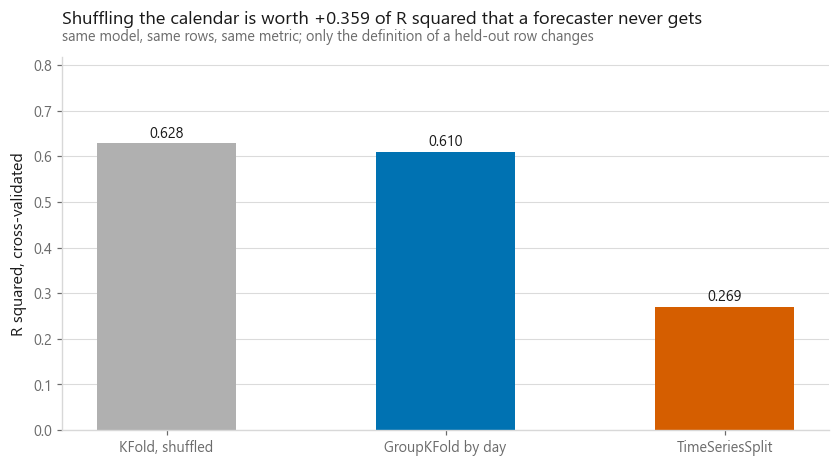

In [12]:
fig, ax = plt.subplots(figsize=(9.0, 4.4))
bars = ax.bar(bike_scores["splitter"], bike_scores["mean R2"],
              color=[style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT], width=0.5)
ax.set_ylim(0, max(bike_scores["mean R2"]) * 1.3)
ax.set_ylabel("R squared, cross-validated")
for bar, value in zip(bars, bike_scores["mean R2"]):
    ax.annotate(f"{value:.3f}", (bar.get_x() + bar.get_width() / 2, value),
                xytext=(0, 4), textcoords="offset points", ha="center",
                fontsize=9.5, color=style.INK)

drop = bike_scores.loc[0, "mean R2"] - bike_scores.loc[2, "mean R2"]
style.title(ax,
            f"Shuffling the calendar is worth {drop:+.3f} of R squared that a forecaster never gets",
            "same model, same rows, same metric; only the definition of a held-out row changes")

style.save(fig, FIG / "fig-04-splitters.png")

Nothing raised an error, and every one of those numbers is correctly computed.
They answer different questions, and the shuffled one answers a question nobody
asked: how well can the model fill a gap in a day it has already seen most of.
[01-04](../04-cross-validation/) works through the full set of splitters and gets
the same ordering on this data.

### Rows that come in time order

The time split is the harsh one, and its harshness is the point. If the model is
going to run on next month's data, the only honest rehearsal is training on the
past and testing on the future. A shuffled split lets the model learn from
December while predicting June.

The picture below is the mechanism rather than the score: which rows end up in
the held-out fold, drawn against the calendar.

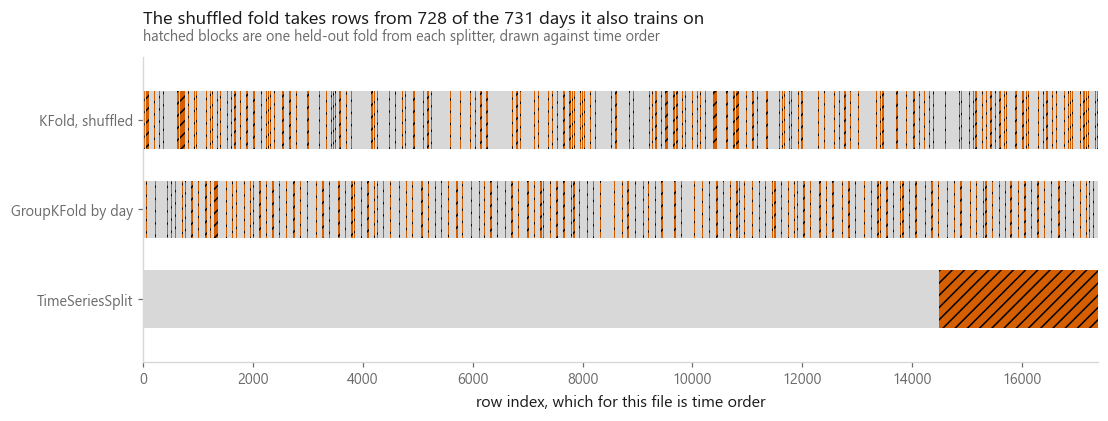

In [13]:
def test_blocks(mask):
    """Contiguous runs of True in `mask`, as (start, length) pairs for broken_barh."""
    padded = np.concatenate(([0], mask.astype(int), [0]))
    edges = np.diff(padded)
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)
    return list(zip(starts, ends - starts))


n = len(X_bike)
layouts = []
for name, (cv, groups) in splits.items():
    folds = list(cv.split(X_bike, y_bike, groups=groups))
    _, held = folds[-1]
    mask = np.zeros(n, dtype=bool)
    mask[held] = True
    layouts.append((name, mask))

fig, ax = plt.subplots(figsize=(11.2, 3.6))
for i, (name, mask) in enumerate(layouts):
    ax.broken_barh([(0, n)], (i - 0.32, 0.64), facecolors=style.RULE)
    ax.broken_barh(test_blocks(mask), (i - 0.32, 0.64),
                   facecolors=style.HIGHLIGHT, hatch="///", edgecolor="none")

ax.set_yticks(range(len(layouts)), [name for name, _ in layouts])
ax.set_xlabel("row index, which for this file is time order")
ax.set_xlim(0, n)
ax.grid(visible=False)
ax.set_ylim(-0.7, len(layouts) - 0.3)
ax.invert_yaxis()          # so the first splitter in the table is the first strip
held_days = pd.Series(days[layouts[0][1]]).nunique()
style.title(ax,
            f"The shuffled fold takes rows from {held_days} of the "
            f"{pd.Series(days).nunique()} days it also trains on",
            "hatched blocks are one held-out fold from each splitter, drawn against time order")

style.save(fig, FIG / "fig-05-what-a-held-out-fold-looks-like.png")

The top strip is a solid speckle, because a shuffled fold takes a fifth of the
hours from every day in the file. The middle strip keeps whole days together.
The bottom strip is one contiguous block at the end, which is the only layout
that matches how the model would be used.

A test set is a claim about what "new data" means. Choose the splitter that
makes that claim true, and the score becomes an estimate of something you care
about.

## Cheat sheet

| | |
|---|---|
| **Training set** | Fits parameters. Anything the algorithm optimises belongs here |
| **Validation set** | Fits your choices. Model family, hyperparameters, stopping point, threshold |
| **Test set** | Touched once, at the end, to produce the number you report |
| **The rule** | A set that decided something is no longer able to measure it |
| **Optimism** | Grows like $\sqrt{2\ln k}$ in the candidate count and shrinks like $1/\sqrt{n}$ in the test size. The test size is the dial worth turning |
| **Small data** | Nested cross-validation instead of a permanent validation set. It scores the procedure, not the model |
| **Never report** | `GridSearchCV.best_score_`. It is a maximum over noise |
| **Repeated rows** | `GroupKFold` or `StratifiedGroupKFold`, grouped by whatever repeats: patient, day, device, session |
| **Time order** | `TimeSeriesSplit`, or a fixed cut by date. Never shuffle a forecast |
| **Next** | [Overfitting and underfitting](../03-overfitting-and-underfitting/), then [cross-validation](../04-cross-validation/) for how to split when rows are scarce |

## What to remember

1. The test set does not measure the model. It measures how much you have
   already looked at it.
2. The optimism is created by choosing, not by overfitting. A simulation where
   every candidate is identical produces it in full.
3. It grows slowly in the number of candidates and shrinks fast in the number of
   test rows. A tiny test set consulted often is the worst combination, and it is
   the most common one.
4. Past the first couple of dozen looks in the measurement above, most of the
   improvement on the reported line was not present in the honest line.
5. Tuning against the test set did not make the model worse here. It made the
   number wrong, which is harder to notice and worse to ship.
6. Nested cross-validation estimates the whole procedure, search included. That
   is the right target when the procedure is what you will rerun.
7. `best_score_` is the maximum of noisy scores and is biased upward for that
   reason alone.
8. A random split assumes rows are exchangeable. Grouped rows and time-ordered
   rows are not, and both fail without raising anything.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [01-03 Overfitting and underfitting](../03-overfitting-and-underfitting/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#ModelEvaluation` `#TrainTestSplit` `#CrossValidation`
`#NestedCV` `#DataLeakage` `#ScikitLearn` `#Python` `#DataScience` `#MLTutorial`